In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
model = load_model("/content/drive/MyDrive/Ayurvedic_project/model.h5")

print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,409 (90.99 MB)

 Trainable params: 263,691 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 6 (36.00 B)

None


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class_names = [
    "Amruta Balli",
    "Ashwagandha",
    "Brahmi",
    "Ekka",
    "Hibiscus",
    "Insulin Plant",
    "Money Plant",
    "Parijata",
    "Sandalwood",
    "Tulsi",
    "Turmeric"
]

In [ ]:
img_path = "/content/drive/MyDrive/Dataset/Ayurvedic/Hibiscus/gg.jpeg"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = preprocess_input(img_array)

img_array = np.expand_dims(img_array, axis=0)

In [ ]:
pred = model.predict(img_array)

pred_class = np.argmax(pred[0])

print("Predicted :", class_names[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Predicted : Hibiscus


In [ ]:
last_conv_layer = None

for layer in reversed(model.layers):

    if isinstance(layer, tf.keras.layers.Conv2D):

        last_conv_layer = layer.name

        break

print(last_conv_layer)

None


In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))

0 resnet50 <class 'keras.src.models.functional.Functional'>
1 global_average_pooling2d_4 <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
2 dense_8 <class 'keras.src.layers.core.dense.Dense'>
3 dropout_4 <class 'keras.src.layers.regularization.dropout.Dropout'>
4 dense_9 <class 'keras.src.layers.core.dense.Dense'>


In [ ]:
def remove_background_green(img):

    r, g, b = tf.unstack(img, axis=-1)

    exg = 2.0 * g - r - b

    exg_min = tf.reduce_min(exg)
    exg_max = tf.reduce_max(exg)

    exg_norm = (exg - exg_min) / (exg_max - exg_min + 1e-5)

    mask = exg_norm > 0.4
    mask = tf.cast(mask, tf.float32)
    mask = tf.expand_dims(mask, axis=-1)

    img_fg = img * mask

    return img_fg

In [ ]:
# ============================================
# CELL 7 — Create Grad-CAM Model
# ============================================

import tensorflow as tf

# Get the ResNet50 base model
base_model = model.get_layer("resnet50")

# Last convolutional layer
last_conv_layer = base_model.get_layer("conv5_block3_out")

# Create model that returns:
# 1. Feature maps from the last conv layer
# 2. Final feature maps from ResNet50
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)

# Classification head (remaining layers after ResNet50)
classifier = tf.keras.Sequential([
    model.layers[1],   # GlobalAveragePooling2D
    model.layers[2],   # Dense(128)
    model.layers[3],   # Dropout
    model.layers[4]    # Output Dense
])

print("Grad-CAM model created successfully.")

Grad-CAM model created successfully.


/content/drive/MyDrive/Dataset/Ayurvedic/Parijata/WhatsApp Image 2026-07-03 at 13.54.04 (3).jpeg
/content/drive/MyDrive/Dataset/Ayurvedic/Parijata/WhatsApp Image 2026-07-03 at 13.54.04 (3).jpeg
Predicted Class: Parijata


/tmp/ipykernel_774/1235840471.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


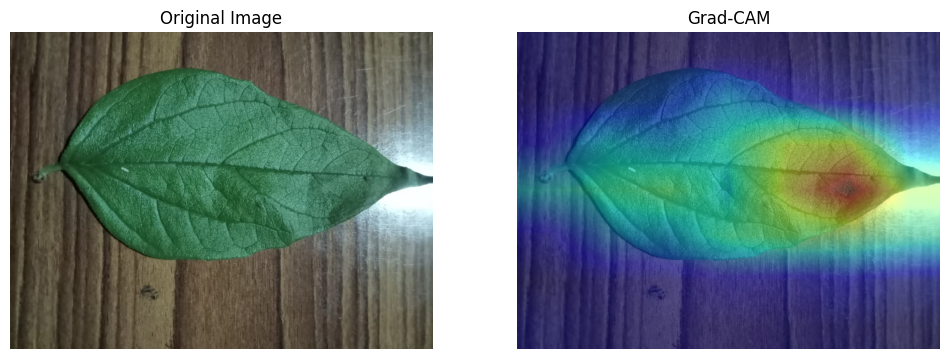

Grad-CAM image saved at 300 DPI.


In [ ]:
# ============================================
# CELL 8 — Generate and Display Grad-CAM
# ============================================

def make_gradcam_heatmap(img_array):

    with tf.GradientTape() as tape:

        conv_outputs, features = grad_model(img_array)

        tape.watch(conv_outputs)

        predictions = classifier(features)

        pred_index = tf.argmax(predictions[0])

        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()



# -------------------------
# Select a test image
# -------------------------
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".jfif", ".webp"}

img_path = "/content/drive/MyDrive/Dataset/Ayurvedic/Parijata/WhatsApp Image 2026-07-03 at 13.54.04 (3).jpeg"

print(img_path)

print(img_path)
# Original image
original = cv2.imread(img_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Load image for prediction
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)

# Same preprocessing used during training
img_array = img_array / 255.0
img_array = remove_background_green(img_array)
img_array = img_array * 255.0
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Prediction
predictions = classifier(grad_model(img_array)[1])
pred_class = np.argmax(predictions[0])

print("Predicted Class:", class_names[pred_class])

heatmap = make_gradcam_heatmap(img_array)

# Convert float16 -> float32
heatmap = np.array(heatmap, dtype=np.float32)

# Resize
heatmap = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0]),
    interpolation=cv2.INTER_LINEAR
)

heatmap = np.uint8(255 * heatmap)

# Apply color map
jet = cm.get_cmap("jet")
jet_heatmap = jet(heatmap)[:, :, :3]
jet_heatmap = np.uint8(jet_heatmap * 255)

# Overlay
superimposed_img = cv2.addWeighted(
    original,
    0.6,
    jet_heatmap,
    0.4,
    0
)

# Display and Save Grad-CAM at 300 DPI
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM")
plt.axis("off")

# Save figure at 300 DPI
plt.savefig(
    "/content/drive/MyDrive/Ayurvedic_project/gradcam_300dpi.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()
plt.close()

print("Grad-CAM image saved at 300 DPI.")

In [ ]:
from pathlib import Path

for f in Path("/content/drive/MyDrive").rglob("*"):
    if f.suffix.lower() in [".keras", ".h5"]:
        print(f)

/content/drive/MyDrive/Ayurvedic_project/model.h5


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/Ayurvedic_project/model.h5")

In [ ]:
conv_outputs, features = grad_model(img_array)

print("Conv output shape:", conv_outputs.shape)
print("Feature shape:", features.shape)

heatmap = make_gradcam_heatmap(img_array)

print(type(heatmap))
print(heatmap.shape)
print(heatmap.dtype)
print(np.min(heatmap))
print(np.max(heatmap))

Conv output shape: (1, 7, 7, 2048)
Feature shape: (1, 7, 7, 2048)
<class 'numpy.ndarray'>
(7, 7)
float16
0.0
1.0
